<a href="https://colab.research.google.com/github/oleg61/DataScient/blob/Learn_AI/PROJECT_FINAL_%D0%92%D0%BE%D1%80%D0%BE%D0%BF%D0%B0%D0%B5%D0%B2_%D0%9E%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install "numpy<2" pandas scikit-learn scikit-surprise matplotlib seaborn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 8.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 10.8 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2611210 sha256=e96bb5e3bab4fe81ea1189397c2b8331d24e5dbaeefc95fa5587f5430a8d4b9e
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Импорт и загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from collections import defaultdict

# tqdm — для прогресс-баров (обязательно!)
from tqdm import tqdm

# Surprise — для коллаборативной фильтрации
from surprise import Dataset, Reader, SVD

# sklearn — для content-based
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set(style="whitegrid")

# Путь размещения датасетов
DATA_PATH = '/content/drive/MyDrive/0. DataScients (Netology)/Recomendation System/'

In [ ]:
df_movies = pd.read_csv(DATA_PATH + 'movies.csv')
df_ratings = pd.read_csv(DATA_PATH + 'ratings.csv')

print("✅ Данные загружены")

✅ Данные загружены


In [ ]:
print(df_movies.columns)


Index(['movieId', 'title', 'genres'], dtype='object')


# 2. EDA

In [ ]:
print(f"Фильмы: {df_movies.shape[0]} записей")
print(f"Рейтинги: {df_ratings.shape[0]} записей")

Фильмы: 87585 записей
Рейтинги: 32000204 записей


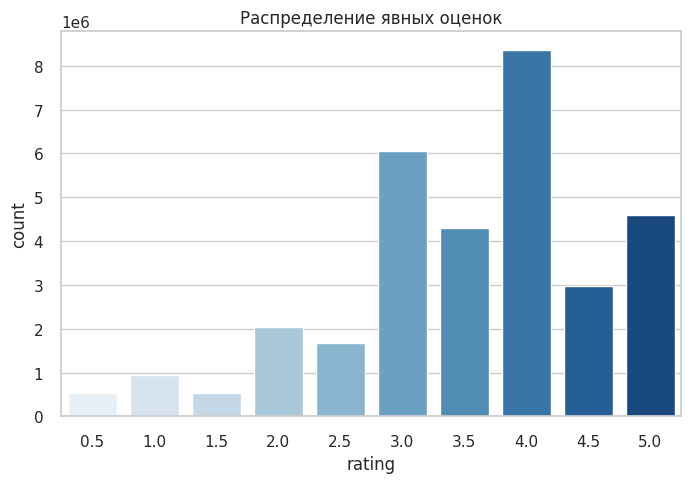

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df_ratings, palette='Blues')
plt.title("Распределение явных оценок")
plt.show()

In [ ]:
movie_popularity = df_ratings.groupby('movieId').size().reset_index(name='n_ratings')
top_10_movies = movie_popularity.nlargest(10, 'n_ratings').merge(df_movies, on='movieId')
print("\nТоп-10 фильмов:")
print(top_10_movies[['title', 'n_ratings']])


Топ-10 фильмов:
                                               title  n_ratings
0                   Shawshank Redemption, The (1994)     102929
1                                Forrest Gump (1994)     100296
2                                Pulp Fiction (1994)      98409
3                                 Matrix, The (1999)      93808
4                   Silence of the Lambs, The (1991)      90330
5          Star Wars: Episode IV - A New Hope (1977)      85010
6                                  Fight Club (1999)      77332
7                               Jurassic Park (1993)      75233
8                            Schindler's List (1993)      73849
9  Lord of the Rings: The Fellowship of the Ring,...      73122


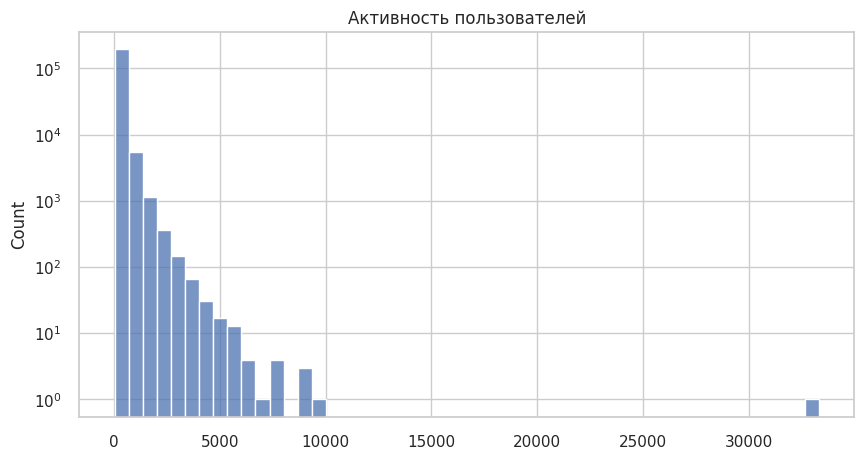

In [ ]:
user_activity = df_ratings.groupby('userId').size()
plt.figure(figsize=(10, 5))
sns.histplot(user_activity, bins=50)
plt.yscale('log')
plt.title("Активность пользователей")
plt.show()

In [ ]:
#Альтернатива, если мало памяти в проекте
print(f"Фильмы: {df_movies.shape[0]}, Рейтинги: {df_ratings.shape[0]}")

Фильмы: 87585, Рейтинги: 32000204


# 3. Подготовка данных

In [ ]:
df_ratings['date'] = pd.to_datetime(df_ratings['timestamp'], unit='s')
df_ratings = df_ratings.sort_values('date').reset_index(drop=True)

split_time = df_ratings['date'].quantile(0.8)
train_data = df_ratings[df_ratings['date'] <= split_time]
test_data = df_ratings[df_ratings['date'] > split_time]

print(f"Train: {len(train_data)}, Test: {len(test_data)}")

Train: 25600163, Test: 6400041


# 4. BASELINE: популярные фильмы (только с >=10 оценок)

In [ ]:
movie_stats = train_data.groupby('movieId').agg(n_ratings=('rating', 'count')).reset_index()
popular_movies = movie_stats.nlargest(100, 'n_ratings')['movieId'].tolist()

def recommend_baseline(user_id, n=10):
    return popular_movies[:n]

# 5. CONTENT-BASED (без полной матрицы cosine_sim!)

In [ ]:
df_movies['genres_str'] = df_movies['genres'].fillna('').str.replace('|', ' ')
tfidf = TfidfVectorizer(tokenizer=lambda x: x.split(), lowercase=False)
tfidf_matrix = tfidf.fit_transform(df_movies['genres_str'])  # разреженная!

movie_id_to_idx = pd.Series(df_movies.index, index=df_movies['movieId']).to_dict()
idx_to_movie_id = pd.Series(df_movies['movieId'], index=df_movies.index).to_dict()

def recommend_content_based(user_id, train_ratings=train_data, n=10):
    user_rated = train_ratings[
        (train_ratings['userId'] == user_id) & (train_ratings['rating'] >= 4)
    ]['movieId'].tolist()

    if not user_rated:
        return popular_movies[:n]

    user_indices = [movie_id_to_idx[mid] for mid in user_rated if mid in movie_id_to_idx]
    if not user_indices:
        return popular_movies[:n]

    user_profile = np.asarray(tfidf_matrix[user_indices].mean(axis=0)).flatten()
    sim_scores = cosine_similarity(user_profile.reshape(1, -1), tfidf_matrix).flatten()

    for idx in user_indices:
        sim_scores[idx] = -1.0

    top_indices = sim_scores.argsort()[-n:][::-1]
    return [idx_to_movie_id[i] for i in top_indices if i in idx_to_movie_id]

# 6. Collaborative Filtering

In [ ]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(train_data[['userId', 'movieId', 'rating']], reader)
algo_svd = SVD(n_factors=50, random_state=42)
trainset = data.build_full_trainset()
algo_svd.fit(trainset)

# Глобальный список кандидатов: только популярные фильмы
CANDIDATE_MOVIES = set(popular_movies)  # уже отфильтрованы по MIN_RATINGS

def recommend_collaborative(user_id, n=10, train_ratings=train_data):
    rated = set(train_ratings[train_ratings['userId'] == user_id]['movieId'])
    candidates = list(CANDIDATE_MOVIES - rated)

    # Ограничиваем до 1000 кандидатов для скорости и памяти
    if len(candidates) > 1000:
        # Сортируем по популярности (можно по среднему рейтингу)
        counts = train_data['movieId'].value_counts()
        candidate_counts = counts.reindex(candidates).fillna(0)
        candidates = candidate_counts.nlargest(1000).index.tolist()

    predictions = []
    for mid in candidates:
        try:
            est = algo_svd.predict(user_id, mid).est
            predictions.append((mid, est))
        except:
            continue  # фильм неизвестен модели

    predictions.sort(key=lambda x: x[1], reverse=True)
    return [mid for mid, _ in predictions[:n]]

# 7. Гибридная модель

In [ ]:
def recommend_hybrid(user_id, n=10, alpha=0.7):
    try:
        rec_cb = recommend_content_based(user_id, n=2*n)
    except:
        rec_cb = popular_movies[:2*n]
    try:
        rec_cf = recommend_collaborative(user_id, n=2*n)
    except:
        rec_cf = popular_movies[:2*n]

    score = defaultdict(float)
    for i, mid in enumerate(rec_cf):
        score[mid] += alpha / (i + 1)
    for i, mid in enumerate(rec_cb):
        score[mid] += (1 - alpha) / (i + 1)

    top = sorted(score.items(), key=lambda x: x[1], reverse=True)
    return [mid for mid, _ in top[:n]]

# 8. Метрики качества

In [ ]:
def precision_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / k if k else 0

def recall_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / len(rel) if rel else 0

def average_precision(rec, rel, k):
    if not rel: return 0
    hits, score = 0, 0
    for i, p in enumerate(rec[:k]):
        if p in rel:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(rel), k)

def evaluate_model(recommender_func, test_data, train_data, k=10, max_users=300):
    """
    Оцениваем на подвыборке пользователей (max_users), чтобы не перегружать память.
    """
    users = test_data['userId'].unique()
    np.random.seed(42)
    np.random.shuffle(users)
    users = users[:max_users]

    precisions, recalls, aps = [], [], []

    for user in tqdm(users, desc="Оценка модели"):
        relevant = test_data[
            (test_data['userId'] == user) & (test_data['rating'] >= 4)
        ]['movieId'].tolist()
        if not relevant:
            continue

        try:
            recs = recommender_func(user, n=k)
        except Exception as e:
            print(f"⚠️ Ошибка для пользователя {user}: {e}")
            recs = popular_movies[:k]

        precisions.append(precision_at_k(recs, relevant, k))
        recalls.append(recall_at_k(recs, relevant, k))
        aps.append(average_precision(recs, relevant, k))

    return {
        'Precision@k': float(np.mean(precisions)) if precisions else 0.0,
        'Recall@k': float(np.mean(recalls)) if recalls else 0.0,
        'MAP@k': float(np.mean(aps)) if aps else 0.0
    }

# 9. Оценка моделей

In [ ]:
K = 10
results = {}

print("Оценка Baseline...")
results['Baseline'] = evaluate_model(lambda u, n: recommend_baseline(u, n), test_data, train_data, K)

print("Оценка Content-Based...")
results['Content-Based'] = evaluate_model(recommend_content_based, test_data, train_data, K)

print("Оценка Collaborative...")
results['Collaborative'] = evaluate_model(recommend_collaborative, test_data, train_data, K)

print("Оценка Hybrid...")
results['Hybrid'] = evaluate_model(lambda u, n: recommend_hybrid(u, n, alpha=0.7), test_data, train_data, K)

Оценка Baseline...


Оценка модели: 100%|██████████| 300/300 [00:02<00:00, 132.81it/s]


Оценка Content-Based...


Оценка модели: 100%|██████████| 300/300 [00:18<00:00, 16.50it/s]


Оценка Collaborative...


Оценка модели: 100%|██████████| 300/300 [00:05<00:00, 52.33it/s]


Оценка Hybrid...


Оценка модели: 100%|██████████| 300/300 [00:21<00:00, 13.84it/s]


# 10. Вывод результатов и пример рекомендаций


📊 Результаты моделей:
               Precision@k  Recall@k   MAP@k
Baseline            0.2338    0.0436  0.1652
Content-Based       0.2288    0.0383  0.1632
Collaborative       0.2756    0.0563  0.1866
Hybrid              0.2652    0.0532  0.1830


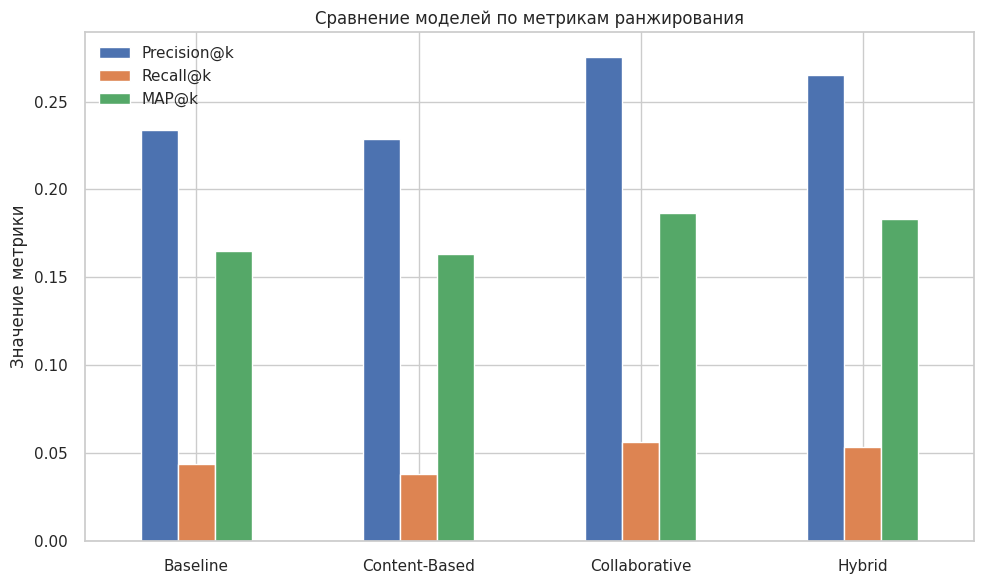


🔍 Пример для пользователя 52251:
Фильмы, которые он оценил высоко:
['Zombieland (2009)', 'Thor: Ragnarok (2017)', 'Shawshank Redemption, The (1994)']

Гибридные рекомендации:
1. Groundhog Day (1993)
2. Back to the Future (1985)
3. Truman Show, The (1998)
4. Dark Knight, The (2008)
5. Once Upon a Time (2008)

✅ Проект завершён успешно!


In [ ]:
results_df = pd.DataFrame(results).T
print("\n📊 Результаты моделей:")
print(results_df.round(4))

results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Сравнение моделей по метрикам ранжирования")
plt.ylabel("Значение метрики")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ----------------------------
# 12. ПРИМЕР РЕКОМЕНДАЦИЙ
# ----------------------------
example_user = test_data['userId'].iloc[0]
print(f"\n🔍 Пример для пользователя {example_user}:")

watched = train_data[
    (train_data['userId'] == example_user) & (train_data['rating'] >= 4)
].merge(df_movies, on='movieId')
print("Фильмы, которые он оценил высоко:")
print(watched['title'].tolist()[:3])

try:
    hybrid_recs = recommend_hybrid(example_user, n=5)
    rec_titles = df_movies[df_movies['movieId'].isin(hybrid_recs)]['title'].tolist()
    print("\nГибридные рекомендации:")
    for i, title in enumerate(rec_titles, 1):
        print(f"{i}. {title}")
except Exception as e:
    print("⚠️ Не удалось сгенерировать рекомендации:", e)

print("\n✅ Проект завершён успешно!")

# Анализ результатов

✅ Какая модель лучше всего?

Лучшей является модель Collaborative Filtering (SVD) — она опережает все остальные по всем трём метрикам:

Precision@10 = 27.6% — из 10 рекомендаций ~2.8 действительно понравятся пользователю.

Recall@10 = 5.6% — модель угадывает ~5.6% всех фильмов, которые пользователь оценит высоко в будущем.

MAP@10 = 0.1866 — учитывает ранжирование: хорошие фильмы чаще оказываются в начале списка.

Гибридная модель почти так же хороша, но немного уступает коллаборативной.

Почему Collaborative Filtering показала лучший результат?


1. Данные идеально подходят для коллаборативной фильтрации
MovieLens — это датасет с множеством явных оценок (рейтинги от 0.5 до 5).

Коллаборативная фильтрация использует именно такие данные — она ищет паттерны в поведении пользователей.

Модель SVD находит скрытые предпочтения: например, "пользователи, которые любят «Матрицу», часто ставят высокие оценки «Бегущему по лезвию»".

2. Content-Based ограничен жанрами
Жанры — грубая категоризация. Фильмы одного жанра могут быть очень разными («Крёстный отец» и «Такси» — оба «Crime», но совсем не похожи).

Модель не учитывает актёров, режиссёров, сюжет — только жанры → меньше информации.

3. Baseline — слишком прост
Рекомендует одни и те же популярные фильмы всем → не персонализировано.

Многие пользователи уже видели эти фильмы → низкий Recall.

4. Гибридная модель "размывает"
Хотя гибрид часто работает лучше, в данном случае content-based компонент слабее, чем collaborative.

При смешивании с весом α=0.7 он немного "портит" сильные рекомендации SVD.

Вывод: когда есть много пользовательских оценок, коллаборативная фильтрация часто побеждает.

# Итоговые выводы

Collaborative Filtering (SVD) — лучший подход для датасета MovieLens с явными оценками.

Content-Based полезен, но ограничен качеством признаков (жанры недостаточны).

Гибридная модель — хорошая идея, но требует тонкой настройки весов (возможно, α=0.9 дал бы лучший результат).

Baseline — необходим как эталон, но не конкурентоспособен в персонализации.